<a href="https://colab.research.google.com/github/tangelladevendarraju-creator/CV-lab-4/blob/main/lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def show_comparison (original, sobel, prewitt, canny):
  plt.figure(figsize=(15,15))

  plt.subplot(2,2,1)
  plt.imshow(original,cmap='gray')
  plt.title('Original Gray Scale Image')
  plt.axis('off')

  plt.subplot(2,2,2)
  plt.imshow(sobel,cmap='gray')
  plt.title('Sobel Edge Detection')
  plt.axis('off')

  plt.subplot(2,2,3)
  plt.imshow(prewitt,cmap='gray')
  plt.title('Prewitt Edge Detection')
  plt.axis('off')

  plt.subplot(2,2,4)
  plt.imshow(canny,cmap='gray')
  plt.title('Canny Edge Detection')
  plt.axis('off')

  plt.tight_layout()
  plt.show()

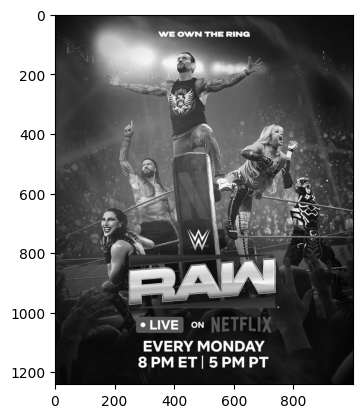

In [ ]:
img = cv2.imread('/content/img1 lab 4.jpg',0)
plt.imshow(img,cmap='gray')
plt.show()

if img is None:
  print('Failed to load image')
else:
  # Convert image to float for gradient calculations to avoid data truncation
  img_float = np.float32(img)

  sobelx = cv2.Sobel(img_float,cv2.CV_64F,1,0,ksize=3)
  sobely = cv2.Sobel(img_float,cv2.CV_64F,0,1,ksize=3)

  # Calculate Sobel magnitude (common way to combine gradients)
  sobel_combined = np.sqrt(sobelx**2 + sobely**2)
  # Normalize the float result to 0-255 and convert to uint8 for display
  sobel_display = cv2.normalize(sobel_combined, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

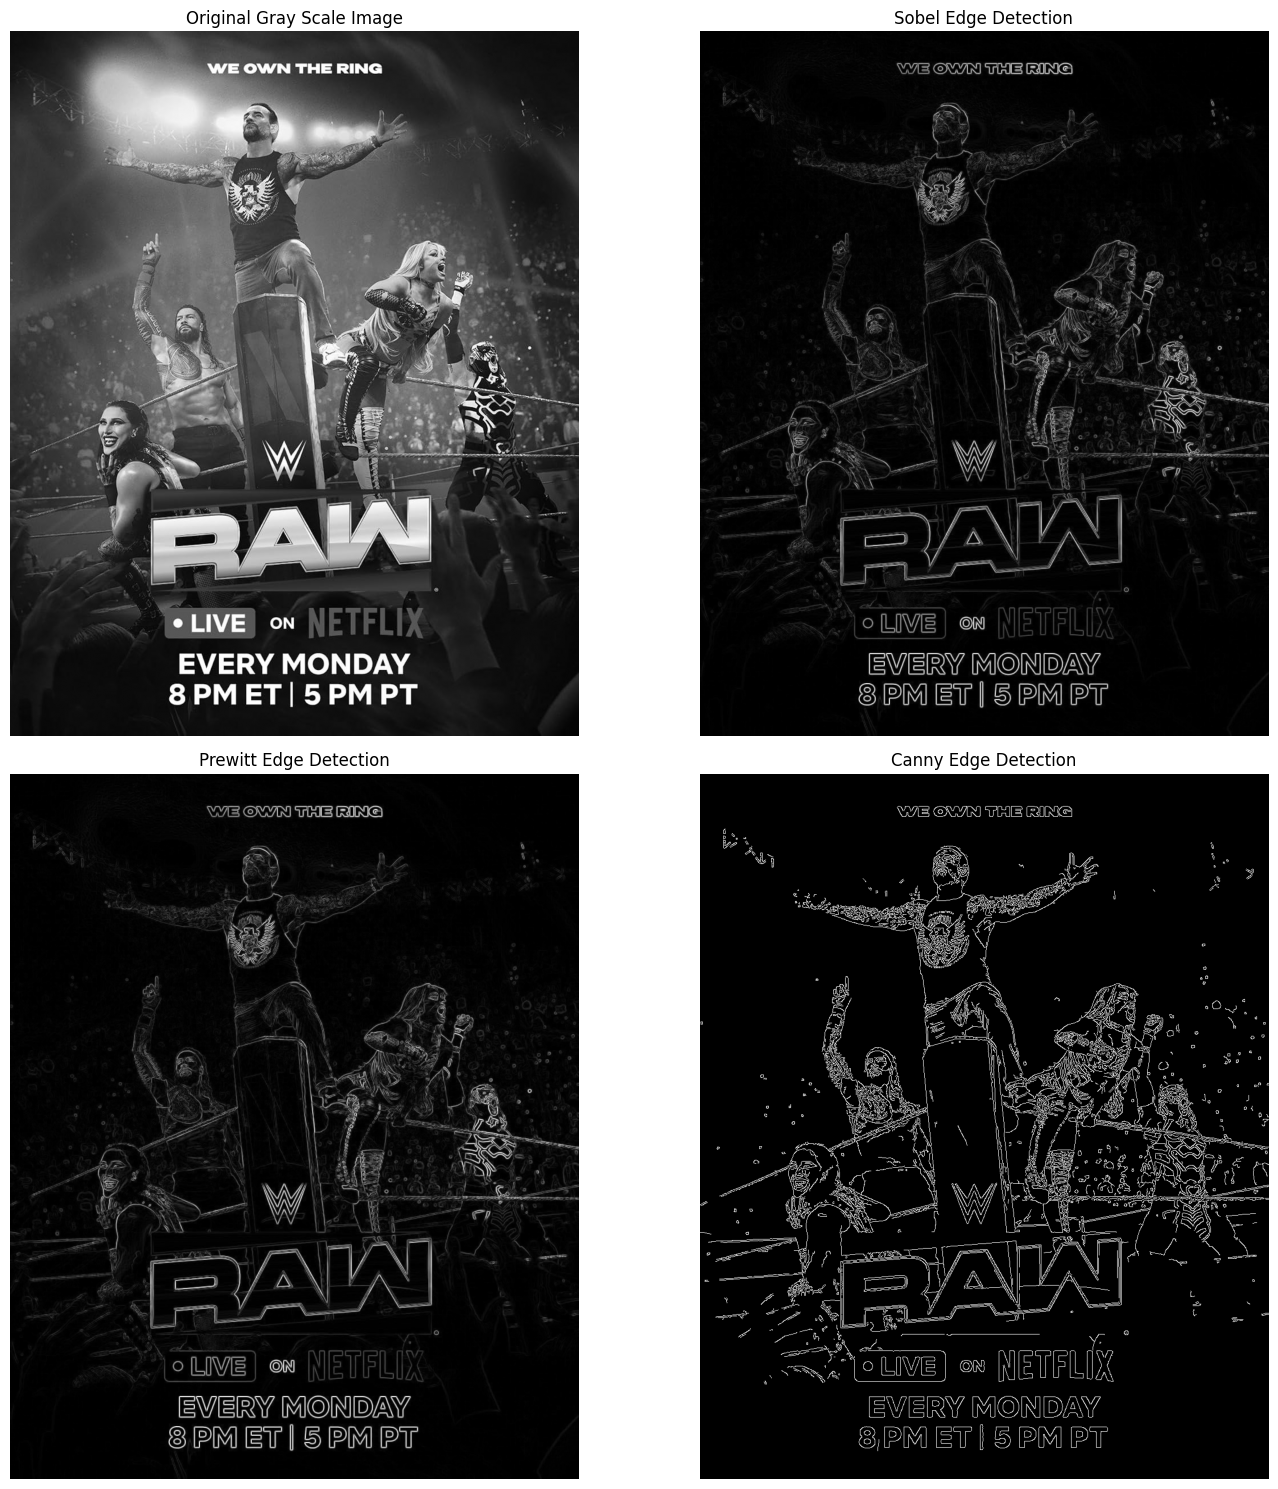

In [ ]:
kernelx = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
kernely = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])

# Apply Prewitt filters to the float image
prewittx = cv2.filter2D(img_float,-1,kernelx) # -1 uses the same depth as the source (float32)
prewitty = cv2.filter2D(img_float,-1,kernely)

# Calculate Prewitt magnitude
prewitt_combined = np.sqrt(prewittx**2 + prewitty**2)
# Normalize the float result to 0-255 and convert to uint8 for display
prewitt_display = cv2.normalize(prewitt_combined, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

canny_edge = cv2.Canny(img,100,200) # Canny expects a uint8 image

show_comparison(img, sobel_display, prewitt_display, canny_edge)